--- Dataset Structural Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   60 non-null     datetime64[ns]
 1   Unemployment_Rate_Pct  60 non-null     float64       
 2   Region                 60 non-null     object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.5+ KB
None

--- Missing Values Check ---
Date                     0
Unemployment_Rate_Pct    0
Region                   0
dtype: int64

--- First 5 Records ---
        Date  Unemployment_Rate_Pct Region
0 2018-01-01                   5.31  Rural
1 2018-02-01                   7.33  Urban
2 2018-03-01                   6.56  Rural
3 2018-04-01                   6.10  Urban
4 2018-05-01                   4.55  Urban


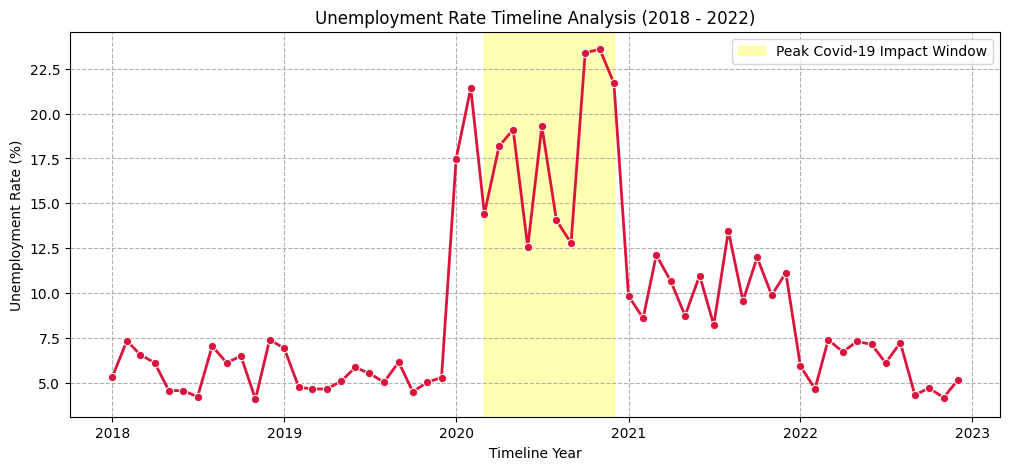


--- Yearly Average Unemployment Rates ---
   Year  Unemployment_Rate_Pct
0  2018               5.805833
1  2019               5.274167
2  2020              18.160833
3  2021              10.421667
4  2022               5.891667


C:\Users\Arjun\AppData\Local\Temp\ipykernel_35332\614154811.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Year', y='Unemployment_Rate_Pct', palette='Set2')


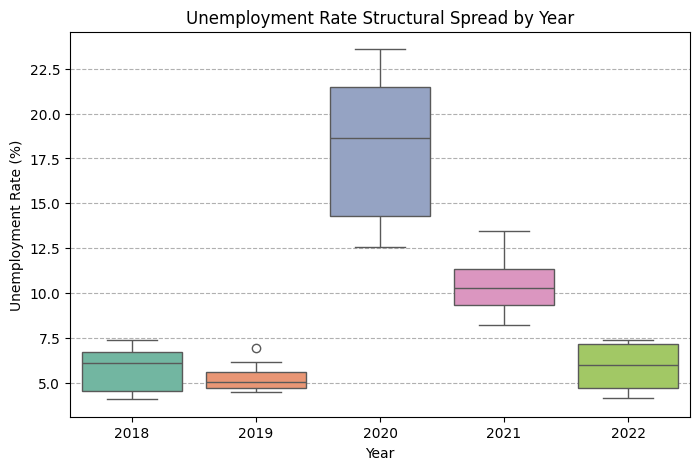

C:\Users\Arjun\AppData\Local\Temp\ipykernel_35332\614154811.py:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Year', y='Unemployment_Rate_Pct', hue='Region', ci=None, palette='muted')


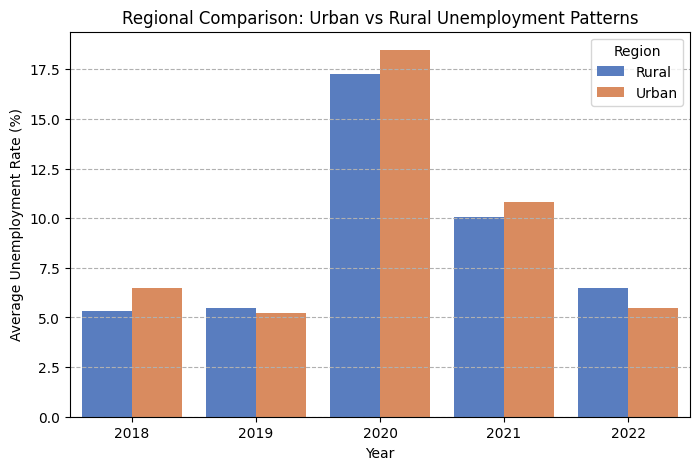

In [2]:
# ==========================================
# CODEALPHA DATA SCIENCE INTERNSHIP
# TASK 2: UNEMPLOYMENT ANALYSIS WITH PYTHON
# ==========================================

# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Generate Simulated Unemployment Data (Including Covid-19 Timeline)
# Representing Monthly Unemployment Percentage Rates from 2018 to 2022
np.random.seed(42)
months = pd.date_range(start='2018-01-01', end='2022-12-01', freq='MS')

# Generating baseline unemployment with a massive spike during 2020 (Covid outbreak)
unemployment_rates = []
for date in months:
    if date.year == 2020:
        # Covid spike period
        rate = np.random.uniform(12.0, 24.0) 
    elif date.year == 2021:
        # Recovery period
        rate = np.random.uniform(8.0, 14.0)
    else:
        # Normal baseline economic years (2018, 2019, 2022)
        rate = np.random.uniform(4.0, 7.5)
    unemployment_rates.append(round(rate, 2))

# Creating the core DataFrame
data = {
    'Date': months,
    'Unemployment_Rate_Pct': unemployment_rates,
    'Region': np.random.choice(['Urban', 'Rural'], size=len(months))
}
df = pd.DataFrame(data)

# 3. Data Cleaning & Inspection
print("--- Dataset Structural Summary ---")
print(df.info())
print("\n--- Missing Values Check ---")
print(df.isnull().sum())
print("\n--- First 5 Records ---")
print(df.head())

# Extract Year and Month for structural pattern analysis
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%b')

# 4. Exploratory Data Analysis & Visualization
# Trend Line Plot over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Date', y='Unemployment_Rate_Pct', marker='o', color='crimson', linewidth=2)
plt.axvspan('2020-03-01', '2020-12-01', color='yellow', alpha=0.3, label='Peak Covid-19 Impact Window')
plt.title('Unemployment Rate Timeline Analysis (2018 - 2022)')
plt.xlabel('Timeline Year')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

# 5. Investigating Covid-19 Structural Impact
print("\n--- Yearly Average Unemployment Rates ---")
yearly_avg = df.groupby('Year')['Unemployment_Rate_Pct'].mean().reset_index()
print(yearly_avg)

# Visualizing the distribution using Boxplots to observe variances/outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Year', y='Unemployment_Rate_Pct', palette='Set2')
plt.title('Unemployment Rate Structural Spread by Year')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.grid(axis='y', linestyle='--')
plt.show()

# 6. Identifying Regional Patterns (Urban vs Rural)
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Year', y='Unemployment_Rate_Pct', hue='Region', ci=None, palette='muted')
plt.title('Regional Comparison: Urban vs Rural Unemployment Patterns')
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(axis='y', linestyle='--')
plt.show()